In [39]:
# ============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import os
#from google.colab import files
import zipfile
from tensorflow.keras import regularizers

In [40]:
import warnings
warnings.filterwarnings("ignore")
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================
# 1. RUTAS
# ============================

base_dir = "../data/selected"   # ajusta si es necesario

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# ============================
# 2. PARÁMETROS
# ============================

img_size = (128, 128)
batch_size = 32
val_split = 0.2   # 20% del train será validación

# ============================
# 3. GENERADORES
# ============================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(rescale=1./255)

# ============================
# 4. DATASETS
# ============================

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Clases detectadas:", train_data.class_indices)
print("Número de clases:", train_data.num_classes)

Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Found 1638 images belonging to 10 classes.
Clases detectadas: {'Apple Golden 1': 0, 'Apple Red 1': 1, 'Banana 1': 2, 'Grape White 1': 3, 'Lemon 1': 4, 'Mango 1': 5, 'Orange 1': 6, 'Peach 1': 7, 'Pear 1': 8, 'Strawberry 1': 9}
Número de clases: 10


In [41]:
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras import layers, models, regularizers

num_classes = 10
model = models.Sequential([

    # Entrada
    layers.Input(shape=(128, 128, 3)),

    # Capa 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Capa 2
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # TRANSICIÓN A DENSAS
    layers.Flatten(),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),

    layers.Dropout(0.4),

    # Capa de SALIDA
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 batch_normalization_12 (Bat  (None, 126, 126, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 32)        9248      
                                                                 
 batch_normalization_13 (Bat  (None, 61, 61, 32)       128       
 chNormalization)                                                
                                                      

In [42]:
import warnings
warnings.filterwarnings("ignore")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)



Fri Feb 27 20:29:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   68C    P8              4W /   50W |     812MiB /   4096MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [44]:
import warnings
warnings.filterwarnings("ignore")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
123/123 [==============================] - 45s 356ms/step - loss: 0.9698 - accuracy: 0.9198 - val_loss: 14.4259 - val_accuracy: 0.1333
Epoch 2/15
  9/123 [=>............................] - ETA: 38s - loss: 0.3680 - accuracy: 0.9931

KeyboardInterrupt: 

52/52 [==============================] - 6s 106ms/step - loss: 23.4412 - accuracy: 0.1502

Precisión en prueba: 0.1502
52/52 [==============================] - 5s 84ms/step

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       0.00      0.00      0.00       160
   Apple Red 1       0.00      0.00      0.00       164
      Banana 1       0.00      0.00      0.00       166
 Grape White 1       0.00      0.00      0.00       166
       Lemon 1       0.00      0.00      0.00       164
       Mango 1       1.00      0.49      0.66       166
      Orange 1       0.00      0.00      0.00       160
       Peach 1       0.00      0.00      0.00       164
        Pear 1       0.00      0.00      0.00       164
  Strawberry 1       0.11      1.00      0.19       164

      accuracy                           0.15      1638
     macro avg       0.11      0.15      0.09      1638
  weighted avg       0.11      0.15      0.09      1638



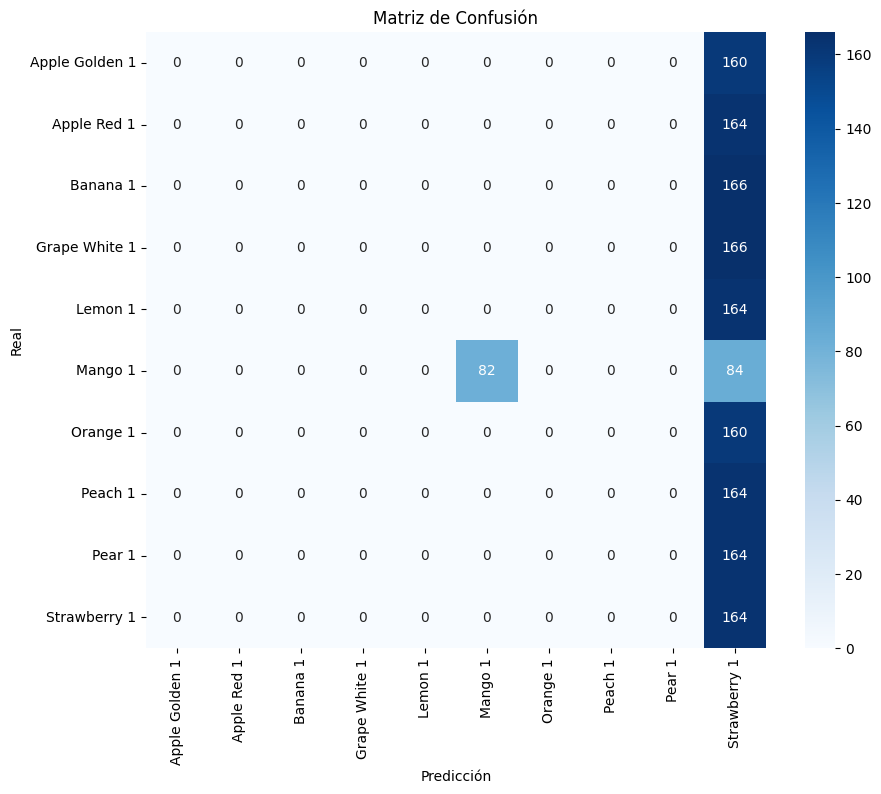

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluación básica
test_loss, test_acc = model.evaluate(test_data)
print(f"\nPrecisión en prueba: {test_acc:.4f}")

# Predicciones
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Reporte
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


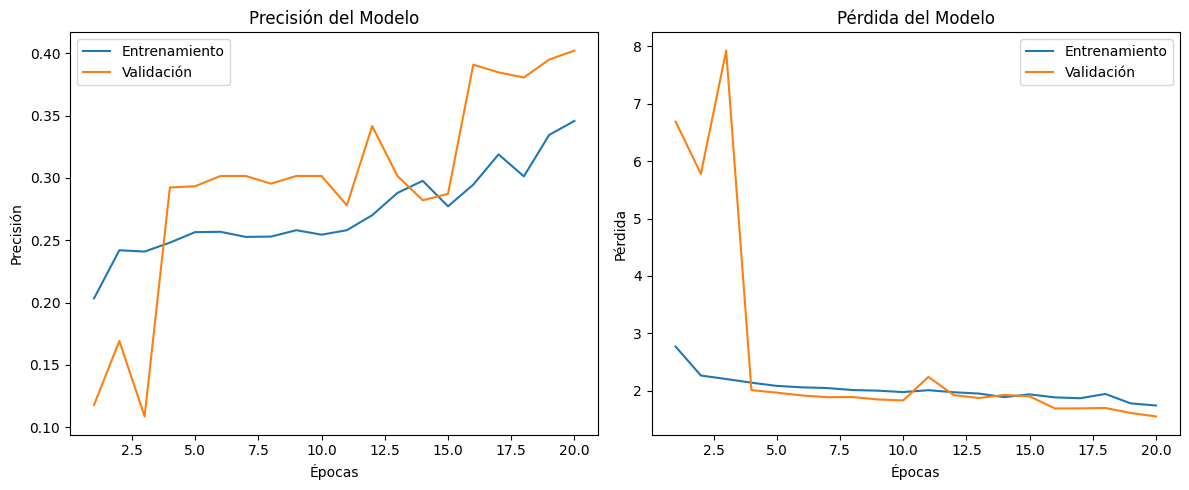


Diagnóstico del modelo:
Posible Underfitting: el modelo no está aprendiendo lo suficiente.


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# ============================
# 6. VISUALIZACIÓN DE MÉTRICAS
# ============================

# Extraer métricas del entrenamiento
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Entrenamiento')
plt.plot(epochs, val_acc, label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Entrenamiento')
plt.plot(epochs, val_loss, label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()


# ============================
# Diagnóstico automático
# ============================

train_acc_final = train_acc[-1]
val_acc_final = val_acc[-1]
train_loss_final = train_loss[-1]
val_loss_final = val_loss[-1]

print("\nDiagnóstico del modelo:")

if train_acc_final < 0.70:
    print("Posible Underfitting: el modelo no está aprendiendo lo suficiente.")
elif val_loss_final > train_loss_final * 1.3:
    print("Overfitting: el modelo aprende demasiado el entrenamiento y no generaliza bien.")
else:
    print("Buen ajuste: el modelo generaliza correctamente.")

In [ ]:
# Métricas del historial
final_acc = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

# Extraer hiperparámetros del modelo
optimizer = model.optimizer
learning_rate = float(optimizer.learning_rate)
optimizer_name = optimizer.__class__.__name__

# Extraer Dropout y Regularización del modelo
dropout_rate = None
l2_value = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dropout):
        dropout_rate = layer.rate
    if hasattr(layer, 'kernel_regularizer') and layer.kernel_regularizer is not None:
        l2_value = layer.kernel_regularizer.l2

# Imprimir resumen
print("=" * 45)
print(f"{'MÉTRICAS DEL MODELO':^45}")
print("=" * 45)
# En vez de tomar del historial, usa el resultado del evaluate
print(f"{'Accuracy (test):':<25} {test_acc:.4f}")
print(f"{'Loss (test):':<25} {test_loss:.4f}")
print(f"{'Val Accuracy:':<25} {history.history['val_accuracy'][-1]:.4f}")
print(f"{'Val Loss:':<25} {history.history['val_loss'][-1]:.4f}")

#print(f"{'Tiempo de ejecución:':<25} {training_time:.2f}s")
print("-" * 45)
print(f"{'HIPERPARÁMETROS':^45}")
print("-" * 45)
print(f"{'Batch Size:':<25} {test_data.batch_size}")
print(f"{'Learning Rate:':<25} {learning_rate}")
print(f"{'Optimizer:':<25} {optimizer_name}")
print(f"{'Regularización L2:':<25} {l2_value}")
print(f"{'Dropout:':<25} {dropout_rate}")
print("=" * 45)

             MÉTRICAS DEL MODELO             
Accuracy (test):          0.4042
Loss (test):              1.6278
Val Accuracy:             0.4021
Val Loss:                 1.5536
---------------------------------------------
               HIPERPARÁMETROS               
---------------------------------------------
Batch Size:               32
Learning Rate:            0.0010000000474974513
Optimizer:                Adam
Regularización L2:        0.0010000000474974513
Dropout:                  0.4
